# Introduction to Data Science - Assignment 1: Exploratory Data Analysis (EDA)
**Author:** Yahav Alkoby  
**Institution:** HIT - Holon Institute of Technology  
**Dataset:** Google Smartphone Decimeter Challenge (`device_gnss_p4xl_train.csv` - Raw GNSS Telemetry)

### Description
This notebook contains a comprehensive Exploratory Data Analysis covering structural metadata, data quality, univariate statistics, correlation matrices, visual suites, index analysis, and domain-specific feature engineering.

### Table of Contents
1. [Environment Setup & Configuration](#1-environment-setup--configuration)
2. [Meta-Analysis & Datastructure Inspection](#2-meta-analysis--datastructure-inspection)
3. [Data Quality & Integrity](#3-data-quality--integrity)
4. [Univariate Analysis & 3 Outlier Methods](#4-univariate-analysis--3-outlier-methods)
5. [Correlations, Cramér's V & Relationships](#5-correlations--relationships)
6. [Visualizations Suite](#6-visualizations-suite)
7. [Index Structure Analysis](#7-index-structure-analysis)
8. [Domain Feature Engineering (Bonus)](#8-domain-feature-engineering-bonus)
9. [Main Execution Pipeline](#9-main-execution-pipeline)


## 1. Environment Setup & Configuration
In this section, we import the necessary libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`) and configure the default visualization styles to ensure our charts are clean and readable. We also suppress warnings to keep the output clean.


In [18]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Configure visualization settings
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
warnings.filterwarnings("ignore")

print("Section 1: Environment setup completed successfully.\n")


Section 1: Environment setup completed successfully.



## 2. Meta-Analysis & Datastructure Inspection
Here, we define a function to load the raw GNSS telemetry data. This function checks the physical file size, the shape of the dataset (rows and columns), and calculates the percentage of missing values (nulls) for every feature.


In [19]:
def load_and_inspect_dataset(file_path: str) -> pd.DataFrame:
    """Loads the CSV dataset and prints comprehensive file and structural metadata."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset not found at path: {file_path}")

    file_size_mb = os.path.getsize(file_path) / (1024 * 1024) # size in MB
    gnss_raw_data = pd.read_csv(file_path)

    print("=" * 70)
    print("SECTION 3: META-ANALYSIS & DATASTRUCTURE INSPECTION")
    print("=" * 70)
    print(f"File Name: {os.path.basename(file_path)}")
    print(f"File Size: {file_size_mb:.2f} MB")
    print(f"Dimensions: {gnss_raw_data.shape[0]:,} rows x {gnss_raw_data.shape[1]} columns")
    print("-" * 70)
    print("Data Types & Null Count per Column:")
    print("-" * 70)
    print(
        pd.DataFrame(
            {
                "Data_Type": gnss_raw_data.dtypes,
                "Non_Null_Count": gnss_raw_data.notnull().sum(),
                "Null_Count": gnss_raw_data.isnull().sum(),
                "Null_Percentage": (gnss_raw_data.isnull().sum() / len(gnss_raw_data)) * 100,
            }
        )
    )
    print("=" * 70 + "\n")
    return gnss_raw_data


## 3. Data Quality & Integrity
A critical step in EDA is ensuring the data conforms to physical realities. This block checks for full row duplicates and verifies domain-specific logic (e.g., Satellite Elevation must be positive, and Carrier-to-Noise density `Cn0DbHz` should logically sit between 10 and 60 dB-Hz). We also check for zero-variance columns.


In [20]:
def analyze_data_quality(df: pd.DataFrame) -> None:
    """Evaluates missing values, exact/partial duplicates, suspicious physical values, and cardinality."""
    print("=" * 70)
    print("SECTION 4: DATA QUALITY & INTEGRITY")
    print("=" * 70)

    # 4.1 Missing Values Analysis
    missing_series = df.isnull().sum()
    print("4.1 Missing Values (Columns with >0 missing entries):")
    print(missing_series[missing_series > 0])

    # 4.2 Duplicate Rows Analysis
    full_duplicates = df.duplicated().sum()
    print(f"\n4.2 Full Row Duplicates: {full_duplicates:,}")

    # 4.3 Suspicious / Impossible Physical Domain Values
    invalid_elevation = (
        df[df["SvElevationDegrees"] < 0] if "SvElevationDegrees" in df.columns else None
    )
    suspicious_cn0 = (
        df[(df["Cn0DbHz"] < 10) | (df["Cn0DbHz"] > 60)] 
        if "Cn0DbHz" in df.columns
        else None
    )

    print(f"4.3 Suspicious Elevation Entries (<0 deg): {0 if invalid_elevation is None else len(invalid_elevation):,}")
    print(f"4.3 Suspicious C/N0 Signal Entries (<10 or >60 dB-Hz): {0 if suspicious_cn0 is None else len(suspicious_cn0):,}")

    # 4.4 Cardinality Analysis
    unique_counts = df.nunique()
    print("\n4.4 Cardinality - Zero Variance Columns (Single unique value):")
    print(unique_counts[unique_counts <= 1])
    print("=" * 70 + "\n")


## 4. Univariate Analysis & 3 Outlier Methods
Here we analyze a specific numerical column to extract fundamental descriptive statistics (Mean, Median, MAD, Skewness). We then apply three robust methodologies for outlier detection:
1. **Standard Z-Score** ($|Z| > 3$)
2. **Tukey's IQR Method** ($1.5 \times \text{IQR}$)
3. **Modified Z-Score** (using Median Absolute Deviation)


In [21]:
def univariate_numerical_analysis(df: pd.DataFrame, column: str) -> None:
    """Performs comprehensive numerical descriptive statistics and applies 3 outlier detection methods."""
    series = df[column].dropna() # remove nan's

    # Calculate required descriptive statistical metrics
    mean_val = series.mean()
    median_val = series.median()
    std_val = series.std()
    mad_val = (series - median_val).abs().mean()  # Mean Absolute Deviation
    iqr_val = series.quantile(0.75) - series.quantile(0.25)
    skewness = series.skew()

    print("=" * 70)
    print(f"SECTION 5.1: UNIVARIATE STATISTICS FOR COLUMN '{column}'")
    print("=" * 70)
    print(f"Mean: {mean_val:.2f}    | Median: {median_val:.2f}  | Std Dev: {std_val:.2f}")
    print(f"MAD:  {mad_val:.2f}    | IQR:    {iqr_val:.2f}  | Skewness: {skewness:.2f}")
    print(f"Min:  {series.min():.2f}    | Max:    {series.max():.2f}")
    print("-" * 70)

    # Outlier Detection Method 1: Standard Z-Score (|Z| > 3)
    z_scores = np.abs(stats.zscore(series))
    outliers_z = series[z_scores > 3]

    # Outlier Detection Method 2: Tukey's IQR Method (1.5 * IQR)
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    outliers_iqr = series[(series < (q1 - 1.5 * iqr_val)) | (series > (q3 + 1.5 * iqr_val))]

    # Outlier Detection Method 3: Modified Z-Score based on Median Absolute Deviation (MAD > 3.5)
    median_absolute_deviation = np.median(np.abs(series - median_val))
    mod_z_scores = (0.6745 * np.abs(series - median_val) / (median_absolute_deviation + 1e-9))
    outliers_mad = series[mod_z_scores > 3.5]

    print(
        f"Outlier Counts -> Method 1 (Z-Score > 3): {len(outliers_z):,} | "
        f"Method 2 (IQR Rule): {len(outliers_iqr):,} | "
        f"Method 3 (Modified MAD > 3.5): {len(outliers_mad):,}"
    )
    print("=" * 70 + "\n")


## 5. Correlations & Relationships
To understand how variables move together, we calculate three types of numerical correlation metrics (Pearson, Spearman, Kendall). Furthermore, we bin the signal strength into categories and apply **Cramér's V** to evaluate the association between the numerical signal and categorical `SignalType`.


In [22]:
def calculate_cramers_v(contingency_table: pd.DataFrame) -> float:
    """Calculates Cramér's V statistic for categorical-categorical correlation."""
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

def analyze_correlations_and_relationships(df: pd.DataFrame) -> None:
    """Evaluates Pearson, Spearman, and Kendall correlations and performs binned Cramér's V test."""
    print("=" * 70)
    print("SECTION 6: CORRELATIONS & INTER-VARIABLE RELATIONSHIPS")
    print("=" * 70)

    # Select core engineering numerical variables
    num_cols = ["SvElevationDegrees", "Cn0DbHz", "RawPseudorangeMeters"]
    num_df = df[num_cols].dropna()

    pearson_corr = num_df.corr(method="pearson")
    spearman_corr = num_df.corr(method="spearman")
    kendall_corr = num_df.corr(method="kendall")

    print("6.1 Pearson Correlation Matrix (Linear Relationships):")
    print(pearson_corr.round(3))
    print("\n6.1 Spearman Rank Correlation Matrix (Monotonic Relationships):")
    print(spearman_corr.round(3))
    print("\n6.1 Kendall Tau Correlation Matrix:")
    print(kendall_corr.round(3))

    # 6.2 Binning numerical signal into categories to measure Cramér's V with SignalType
    df_binned = df.copy()
    df_binned["Signal_Strength_Bin"] = pd.qcut(
        df_binned["Cn0DbHz"],
        q=4,
        labels=["Weak", "Moderate", "Strong", "Excellent"],
    )
    contingency = pd.crosstab(df_binned["SignalType"], df_binned["Signal_Strength_Bin"])
    v_stat = calculate_cramers_v(contingency)

    print("-" * 70)
    print(f"6.2 Cramér's V Correlation (SignalType vs Binned C/N0): {v_stat:.3f}")
    print("=" * 70 + "\n")


## 6. Visualizations Suite
This massive visualization suite uses `matplotlib` and `seaborn` to generate insights. It includes:
* **Scatterplots** (e.g., Line of Sight Elevation vs C/N0).
* **Histograms & Bar charts** (Frequency counts, SV IDs).
* **Boxplots & Violinplots** (Distribution metrics broken down by Signal and Constellation).
* **Heatmaps** for Correlation.
* **Time-Series style tracking** (Evaluating satellite signal stability over time).


In [23]:
def plot_comprehensive_visualizations(df: pd.DataFrame) -> None:
    """Generates all required EDA visualizations with full titles, axes labels, and legends."""
    print("Generating Section 6.3 visualization suite...\n")

    # Filter GPS L1 satellites for clean engineering display
    clean_gps = df[(df["ConstellationType"] == 1) & (df["SignalType"] == "GPS_L1_CA")].copy()

    # 1. Scatterplot: Elevation vs C/N0
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=clean_gps, x="SvElevationDegrees", y="Cn0DbHz", alpha=0.4, color="dodgerblue", label="Observed")
    plt.title("Scatterplot: Signal Strength (C/N0) vs. Elevation Angle (GPS L1)", fontsize=14)
    plt.xlabel("Elevation Angle [Degrees]", fontsize=12)
    plt.ylabel("C/N0 [dB-Hz]", fontsize=12)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # 2. Histogram: C/N0 Distribution
    plt.figure(figsize=(9, 5))
    sns.histplot(clean_gps["Cn0DbHz"], bins=35, kde=True, color="teal", label="C/N0 Frequency")
    plt.title("Histogram: Distribution of Carrier-to-Noise Density (C/N0)", fontsize=14)
    plt.xlabel("C/N0 [dB-Hz]", fontsize=12)
    plt.ylabel("Measurement Count", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3. Barchart: Top Svid Frequency Counts
    plt.figure(figsize=(10, 5))
    top_svids = clean_gps["Svid"].value_counts().head(10)
    sns.barplot(x=top_svids.index, y=top_svids.values, palette="viridis", legend=False)
    plt.title("Barchart: Top 10 Most Frequently Tracked GPS Satellites (Svid)", fontsize=14)
    plt.xlabel("Satellite ID (Svid)", fontsize=12)
    plt.ylabel("Observation Count", fontsize=12)
    plt.tight_layout()
    plt.show()

    # 4. barplot: elevation mean by Constellation Type
    const_std = df.groupby("ConstellationType")["SvElevationDegrees"].mean().reset_index()
    plt.figure(figsize=(8, 5))
    sns.barplot(data=const_std, x="ConstellationType", y="SvElevationDegrees", palette="viridis")
    plt.title("SvElevationDegrees mean per Signal Band", fontsize=14)
    plt.xlabel("RF Signal Type", fontsize=12)
    plt.ylabel("SvElevationDegrees [Degrees]", fontsize=12)
    plt.show()

    # 5. barplot: c/n0 mean across Signals
    const_std_cn0 = df.groupby("ConstellationType")["Cn0DbHz"].mean().reset_index()
    plt.figure(figsize=(8, 5))
    sns.barplot(data=const_std_cn0, x="ConstellationType", y="Cn0DbHz", palette="viridis")
    plt.title("c/n0 mean per Signal Band", fontsize=14)
    plt.xlabel("RF Signal Type", fontsize=12)
    plt.ylabel("c/n0 [dB/Hz]", fontsize=12)
    plt.show()

    # 6. Boxplot: C/N0 by Constellation Type
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x="ConstellationType", y="Cn0DbHz", palette="Blues", showfliers=True)
    plt.title("Boxplot: Signal Strength Across Different GNSS Constellations", fontsize=14)
    plt.xlabel("GNSS Constellation Identifier", fontsize=12)
    plt.ylabel("C/N0 [dB-Hz]", fontsize=12)
    plt.tight_layout()
    plt.show()

    # 7. Piechart: Proportion of Signal Types
    plt.figure(figsize=(7, 7))
    signal_counts = df["SignalType"].value_counts()
    plt.pie(signal_counts, labels=signal_counts.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
    plt.title("Piechart: Distribution of Tracked RF Signal Types", fontsize=14)
    plt.show()

    # 8. Violinplot: Elevation Angle Distribution across Signals
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=df, x="SignalType", y="SvElevationDegrees", palette="mako")
    plt.title("Violinplot: Elevation Angle Spread per Signal Band", fontsize=14)
    plt.xlabel("RF Signal Type", fontsize=12)
    plt.ylabel("Elevation Angle [Degrees]", fontsize=12)
    plt.tight_layout()
    plt.show()

    # 9. Heatmap: Spearman Correlation Matrix
    plt.figure(figsize=(8, 6))
    num_cols = ["SvElevationDegrees", "Cn0DbHz", "RawPseudorangeMeters"]
    sns.heatmap(df[num_cols].corr(method="spearman"), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Heatmap: Spearman Rank Correlation Matrix", fontsize=14)
    plt.tight_layout()
    plt.show()

    # 10. Scatterplot: time vs C/N0 (most seen svid)
    svid_max_time_appers = df[(df["ConstellationType"] == 1) & (df["SignalType"] == "GPS_L1_CA")].copy()
    svid_max = svid_max_time_appers["Svid"].value_counts().index[0]
    svid_max_time_appers= svid_max_time_appers[svid_max_time_appers["Svid"]==svid_max]

    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=svid_max_time_appers, x=(svid_max_time_appers["TimeNanos"] / 1e9)/60, 
        y="Cn0DbHz", alpha=0.4, color="dodgerblue"
    )
    plt.title("SV C/N0 vs Time (SV with the max time appers)", fontsize=14)
    plt.xlabel("time [min]", fontsize=12)
    plt.ylabel("C/N0 [dB-Hz]", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Filter svids with >= 50 counts
    gps_l1 = df[(df["ConstellationType"] == 1) & (df["SignalType"] == "GPS_L1_CA")].copy()
    valid_svids = gps_l1.groupby("Svid")["Cn0DbHz"].count()[lambda x: x >= 50].index
    gps_l1_filtered = gps_l1[gps_l1["Svid"].isin(valid_svids)]

    std_per_svid = gps_l1_filtered.groupby("Svid")["Cn0DbHz"].std()
    svid_least_changed = std_per_svid.idxmin()
    svid_most_changed = std_per_svid.idxmax()

    # 11. C/N0 vs Time for Max/Min Std Svids
    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=gps_l1_filtered[gps_l1_filtered["Svid"]==svid_most_changed],
        x=(gps_l1_filtered[gps_l1_filtered["Svid"]==svid_most_changed]["TimeNanos"]/ 1e9)/60,
        y="Cn0DbHz", alpha=0.4, color="dodgerblue"
    )
    plt.title("SV C/N0 vs Time (SV with the max std in the c/n0)", fontsize=14)
    plt.xlabel("time [min]", fontsize=12)
    plt.ylabel("C/N0 [dB-Hz]", fontsize=12)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=gps_l1_filtered[gps_l1_filtered["Svid"]==svid_least_changed],
        x=(gps_l1_filtered[gps_l1_filtered["Svid"]==svid_least_changed]["TimeNanos"]/ 1e9)/60,
        y="Cn0DbHz", alpha=0.4, color="dodgerblue"
    )
    plt.title("SV C/N0 vs Time (SV with the min std in the c/n0)", fontsize=14)
    plt.xlabel("time [min]", fontsize=12)
    plt.ylabel("C/N0 [dB-Hz]", fontsize=12)
    plt.tight_layout()
    plt.show()

    # 12. Elevation vs time for Max/Min Std Svids
    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=gps_l1_filtered[gps_l1_filtered["Svid"]==svid_most_changed],
        x=(gps_l1_filtered[gps_l1_filtered["Svid"]==svid_most_changed]["TimeNanos"]/1e9)/60,
        y="SvElevationDegrees", alpha=0.4, color="dodgerblue"
    )
    plt.title("SvElevationDegrees vs Time (SV with the max std in the c/n0)", fontsize=14)
    plt.xlabel("time [min]", fontsize=12)
    plt.ylabel("Elevation Angle [Degrees]", fontsize=12)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=gps_l1_filtered[gps_l1_filtered["Svid"]==svid_least_changed],
        x=(gps_l1_filtered[gps_l1_filtered["Svid"]==svid_least_changed]["TimeNanos"]/1e9)/60,
        y="SvElevationDegrees", alpha=0.4, color="dodgerblue"
    )
    plt.title("SvElevationDegrees vs Time (SV with the min std in the c/n0)", fontsize=14)
    plt.xlabel("time [min]", fontsize=12)
    plt.ylabel("Elevation Angle [Degrees]", fontsize=12)
    plt.tight_layout()
    plt.show()


## 7. Index Structure Analysis
For Time-Series and Telemetry data, checking how the data is indexed is crucial. This snippet validates if the dataset rows are inherently sorted by GNSS Epoch time and whether the index contains duplicate values.


In [24]:
def inspect_index_structure(df: pd.DataFrame) -> None:
    """Evaluates index uniqueness, temporal ordering, and monotonicity."""
    print("=" * 70)
    print("SECTION 7: INDEX STRUCTURE ANALYSIS")
    print("=" * 70)
    print(f"Is DataFrame Index Unique? -> {df.index.is_unique}")
    print(f"Is DataFrame Index Monotonically Increasing? -> {df.index.is_monotonic_increasing}")

    # Check temporal ordering behavior using GPS Epoch Time
    if "ReceivedSvTimeNanosSinceGpsEpoch" in df.columns:
        is_time_sorted = df["ReceivedSvTimeNanosSinceGpsEpoch"].is_monotonic_increasing
        print(f"Is Dataset Monotonically Sorted by GPS Time? -> {is_time_sorted}")
    print("=" * 70 + "\n")


## 8. Domain Feature Engineering (Bonus)
A major component of GNSS analysis is discerning clean Line-of-Sight (LOS) signals from Multipath (bounced) signals. This function engineers a new boolean column `Is_Reliable_LOS`, classifying a signal as reliable if it is both high in the sky ($\geq 40^\circ$) and carries a strong signal ($\geq 37$ dB-Hz).


In [25]:
def engineer_domain_features(df: pd.DataFrame) -> pd.DataFrame:
    """Creates domain-specific feature for Line-of-Sight (LOS) vs. Multipath classification."""
    enhanced_df = df.copy()

    # Feature Engineering: Reliable Line-of-Sight (LOS) Classifier
    # Logical Engineering Rule: High elevation (>=40 deg) AND Strong carrier-to-noise ratio (>=37 dB-Hz)
    enhanced_df["Is_Reliable_LOS"] = np.where(
        (enhanced_df["SvElevationDegrees"] >= 40) & (enhanced_df["Cn0DbHz"] >= 37),
        1,
        0,
    )

    los_percentage = (enhanced_df["Is_Reliable_LOS"].mean()) * 100
    print("=" * 70)
    print("SECTION 9 (BONUS): DOMAIN FEATURE ENGINEERING")
    print("=" * 70)
    print("Engineered new domain feature: 'Is_Reliable_LOS'")
    print(f"Reliable Line-of-Sight (LOS) Measurements in Dataset: {los_percentage:.2f}%")
    print("=" * 70 + "\n")
    return enhanced_df


## 9. Execution Pipeline
In a Jupyter Notebook environment, you can run functions independently. However, to execute the full pipeline exactly as intended in the original Python script, simply run the cell below.

*(Make sure `device_gnss_train_p4xl.csv` is in the same directory as this notebook).*


SECTION 3: META-ANALYSIS & DATASTRUCTURE INSPECTION
File Name: device_gnss_train_p4xl.csv
File Size: 30.55 MB
Dimensions: 48,481 rows x 58 columns
----------------------------------------------------------------------
Data Types & Null Count per Column:
----------------------------------------------------------------------
                                          Data_Type  Non_Null_Count  \
MessageType                                     str           48481   
utcTimeMillis                                 int64           48481   
TimeNanos                                     int64           48481   
LeapSecond                                    int64           48481   
TimeUncertaintyNanos                        float64               0   
FullBiasNanos                                 int64           48481   
BiasNanos                                   float64           48481   
BiasUncertaintyNanos                        float64           48481   
DriftNanosPerSecond                 

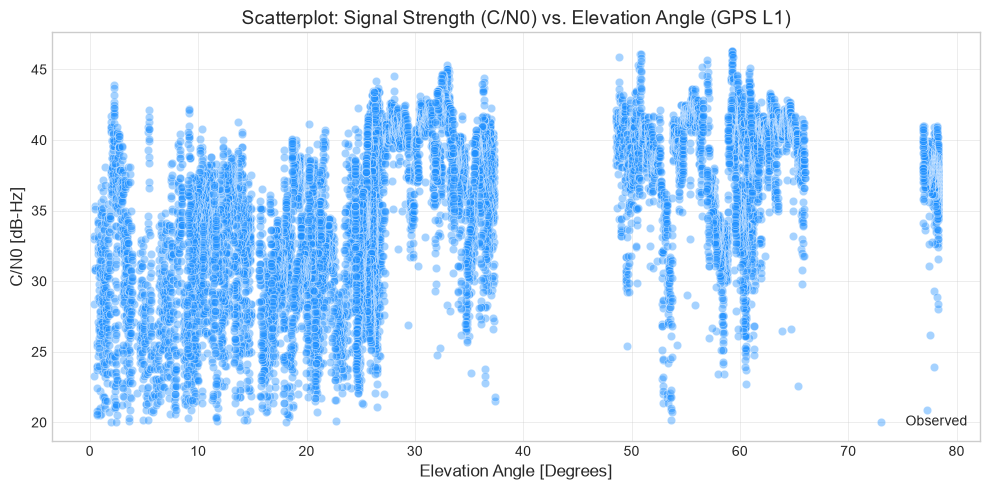

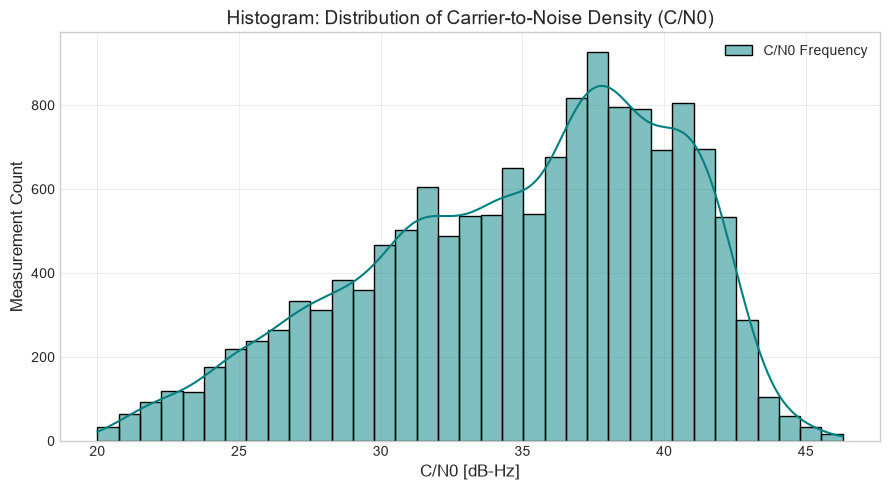

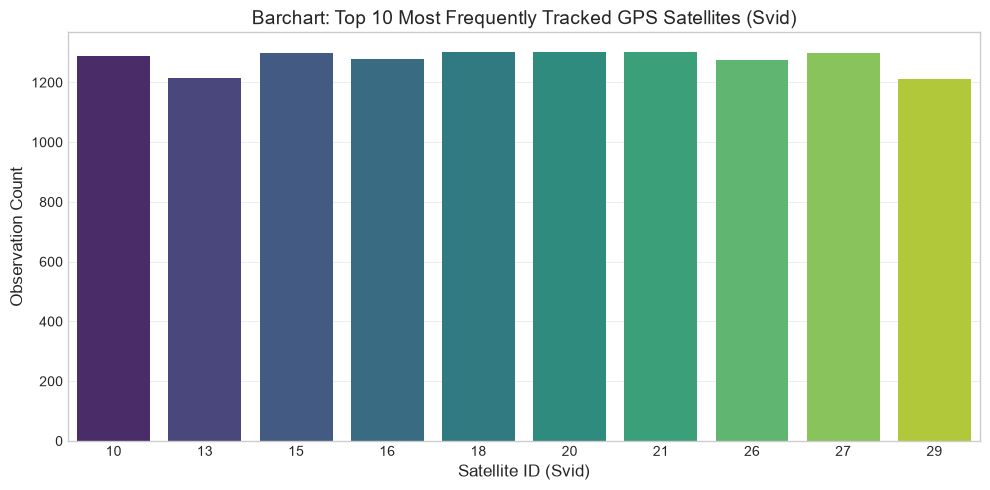

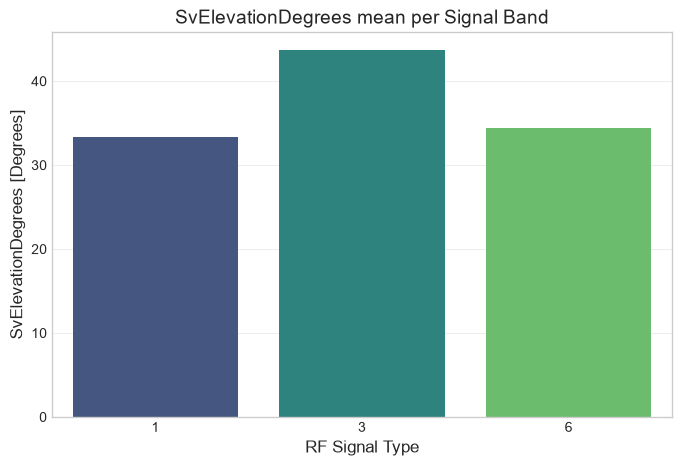

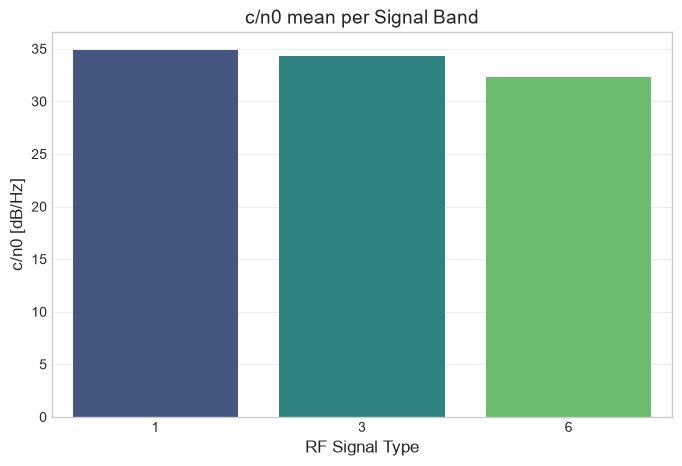

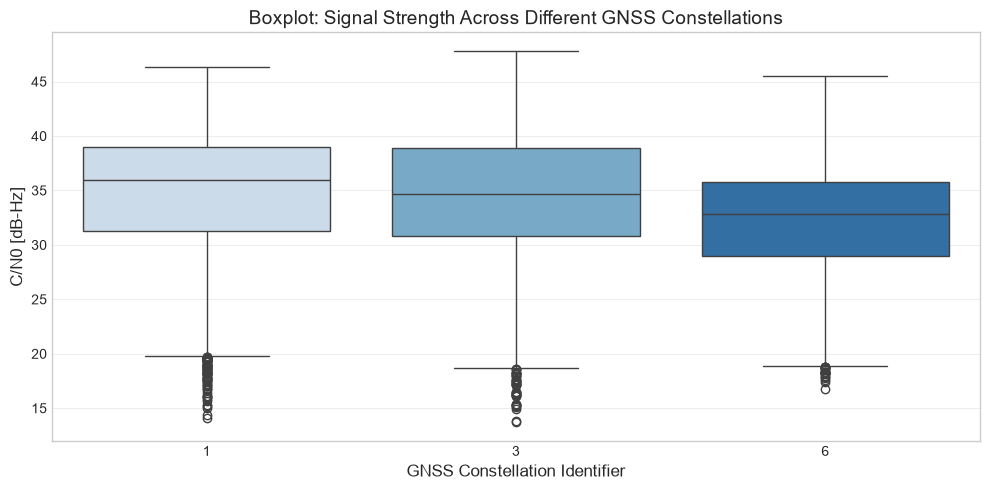

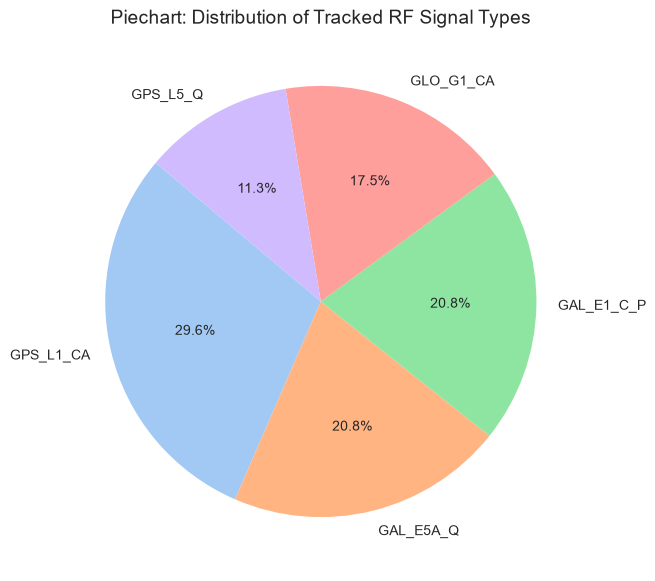

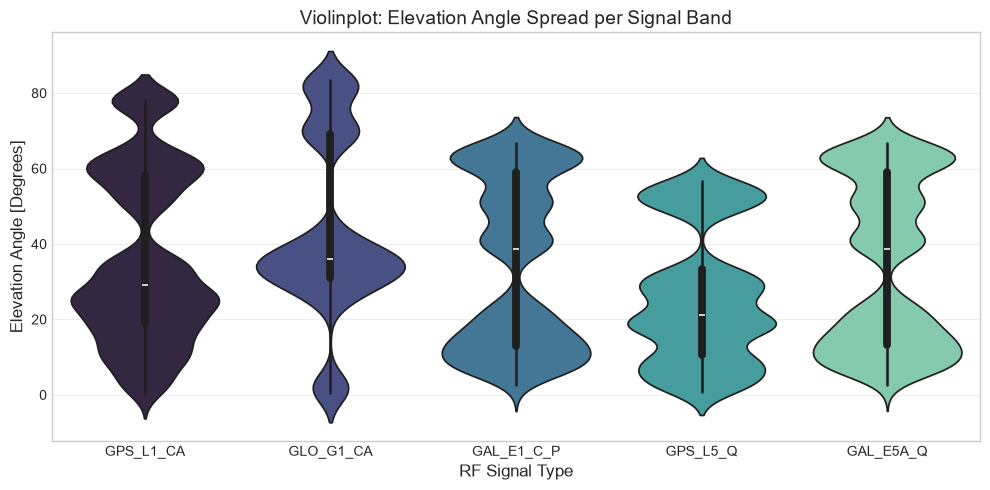

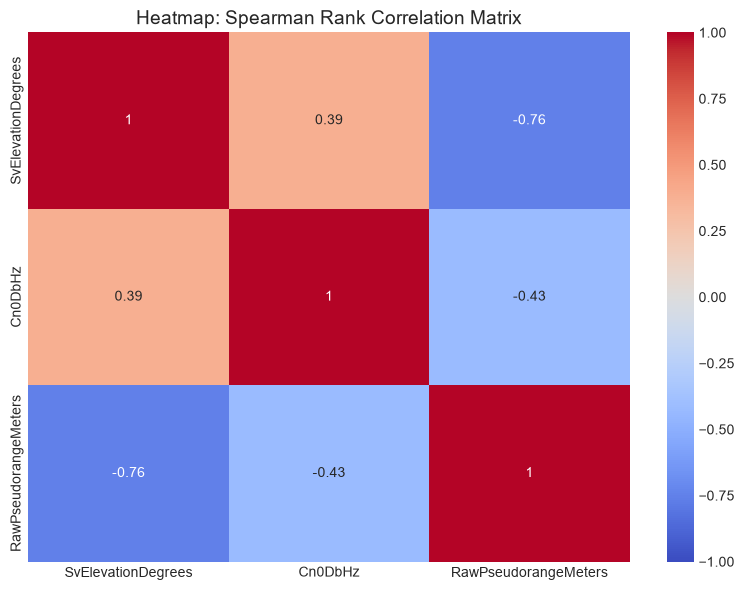

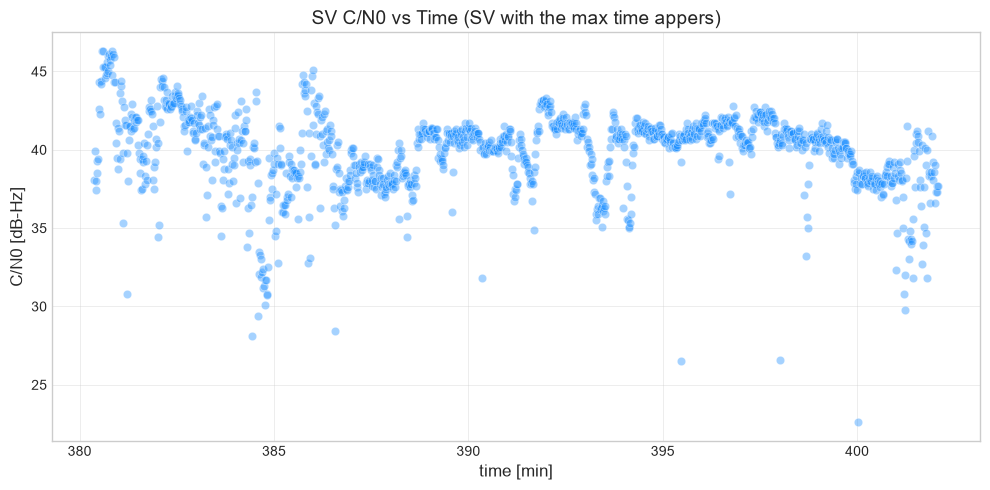

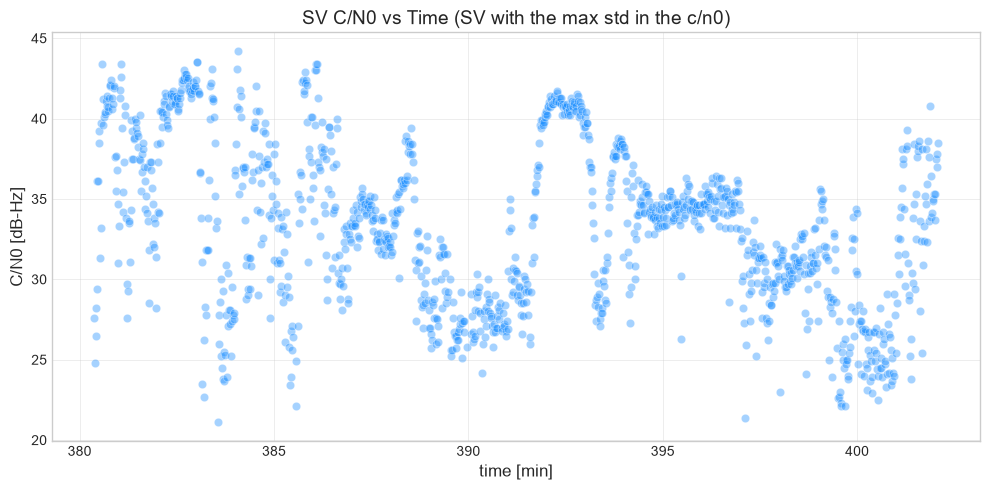

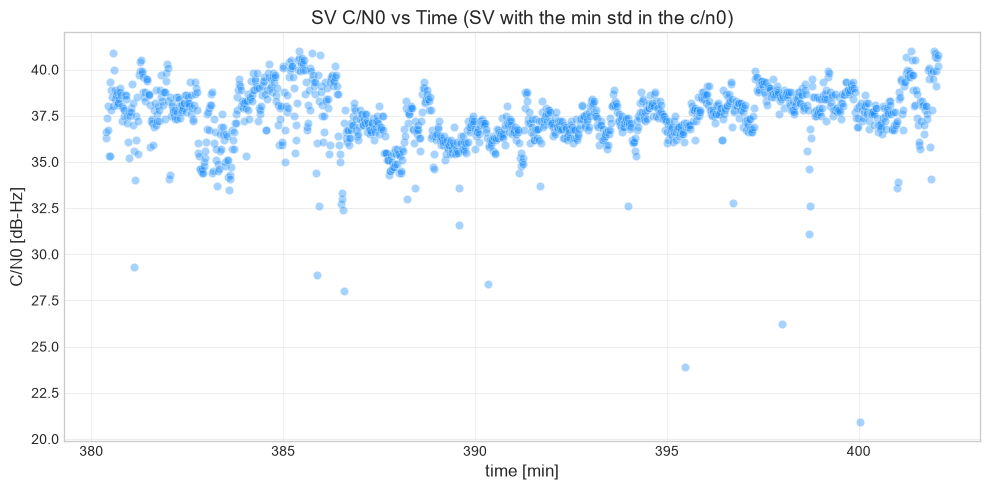

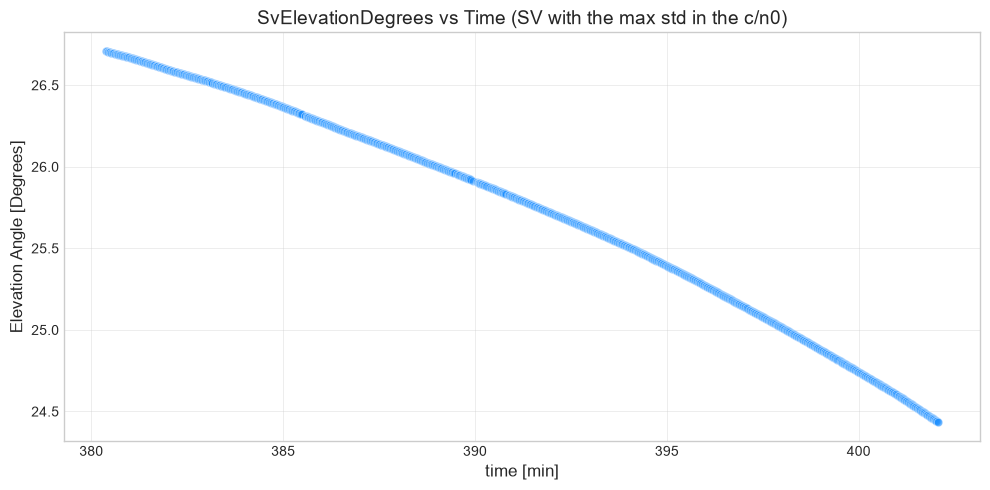

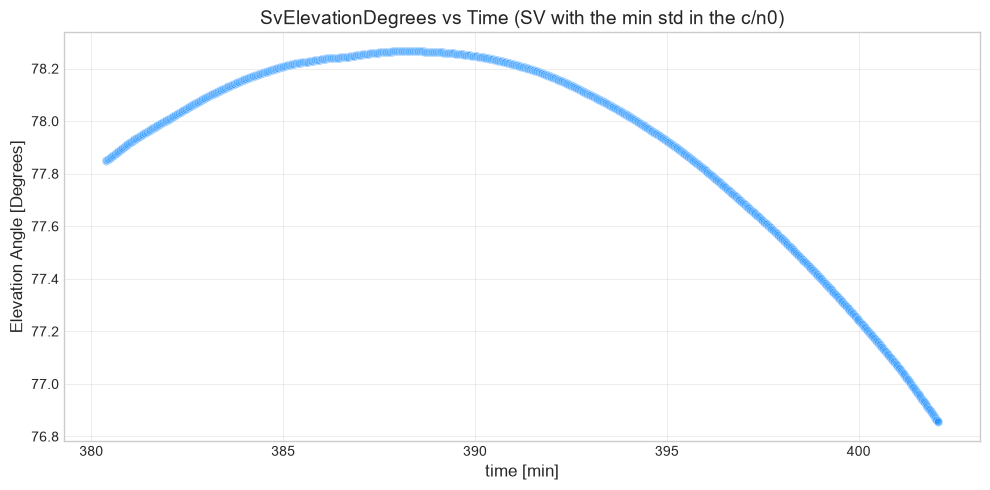

SECTION 7: INDEX STRUCTURE ANALYSIS
Is DataFrame Index Unique? -> True
Is DataFrame Index Monotonically Increasing? -> True
Is Dataset Monotonically Sorted by GPS Time? -> False

SECTION 9 (BONUS): DOMAIN FEATURE ENGINEERING
Engineered new domain feature: 'Is_Reliable_LOS'
Reliable Line-of-Sight (LOS) Measurements in Dataset: 16.71%

EDA execution pipeline completed successfully. Ready for report synthesis.


In [26]:
def main():
    """Main execution entry point running the full EDA pipeline."""
    dataset_path = "device_gnss_train_p4xl.csv"

    try:
        gnss_df = load_and_inspect_dataset(dataset_path)

        # Step 2: Quality and Integrity Analysis
        analyze_data_quality(gnss_df)

        # Step 3: Univariate Analysis and Outliers Detection
        univariate_numerical_analysis(gnss_df, "Cn0DbHz")

        # Step 4: Inter-Variable Correlations and Relationships
        analyze_correlations_and_relationships(gnss_df)

        # Step 5: Comprehensive Visualizations Suite
        plot_comprehensive_visualizations(gnss_df)

        # Step 6: Index Analysis
        inspect_index_structure(gnss_df)

        # Step 7: Bonus Feature Engineering
        gnss_df = engineer_domain_features(gnss_df)

        print("EDA execution pipeline completed successfully. Ready for report synthesis.")

    except FileNotFoundError as e:
        print(f"Error: {e}")
        print("Please ensure the CSV file is located in the same folder as this notebook.")

if __name__ == "__main__":
    main()
